In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("teen_phone_addiction_dataset.csv")

### Question 1

Check Below
- DataFrame Shape
- Data Types
- Duplicate records (remove if found)
- Missing/Null Values (replace with median value)

In [8]:
# 1. Display DataFrame Shape
print("DataFrame Shape:", df.shape)

DataFrame Shape: (3000, 25)


In [10]:
# 2. Display Data Types
print("\nData Types:\n", df.dtypes)


Data Types:
 ID                          int64
Name                       object
Age                         int64
Gender                     object
Location                   object
School_Grade               object
Daily_Usage_Hours         float64
Sleep_Hours               float64
Academic_Performance        int64
Social_Interactions         int64
Exercise_Hours            float64
Anxiety_Level               int64
Depression_Level            int64
Self_Esteem                 int64
Parental_Control            int64
Screen_Time_Before_Bed    float64
Phone_Checks_Per_Day        int64
Apps_Used_Daily             int64
Time_on_Social_Media      float64
Time_on_Gaming            float64
Time_on_Education         float64
Phone_Usage_Purpose        object
Family_Communication        int64
Weekend_Usage_Hours       float64
Addiction_Level           float64
dtype: object


In [12]:
# 3. Check and Remove Duplicate Records
duplicate_count = df.duplicated().sum()
print("\nNumber of Duplicate Records:", duplicate_count)
df = df.drop_duplicates()


Number of Duplicate Records: 0


In [14]:
# 4. Check for Missing/Null Values
print("\nMissing Values Before:\n", df.isnull().sum())


Missing Values Before:
 ID                         0
Name                       0
Age                        0
Gender                     0
Location                   0
School_Grade               0
Daily_Usage_Hours          5
Sleep_Hours                0
Academic_Performance       0
Social_Interactions        0
Exercise_Hours             8
Anxiety_Level              0
Depression_Level           0
Self_Esteem                0
Parental_Control           0
Screen_Time_Before_Bed    15
Phone_Checks_Per_Day       0
Apps_Used_Daily            0
Time_on_Social_Media       0
Time_on_Gaming             0
Time_on_Education          0
Phone_Usage_Purpose        0
Family_Communication       0
Weekend_Usage_Hours        0
Addiction_Level            0
dtype: int64


In [16]:
# 5. Replace Missing Values with Median (for numeric columns only)
numeric_columns = df.select_dtypes(include='number').columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

In [18]:
# 6. Confirm Missing Values Handled
print("\nMissing Values After:\n", df.isnull().sum())


Missing Values After:
 ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64


### Question 2:

How does time spent on social media compare to time spent on education among teens?

- Plot side-by-side histograms of Time on Social Media and Time on Education
- Find and compare the median time for both.
- Write simple comments to explain what the data shows

In [ ]:
# Replace missing values if any (optional)
df.fillna(df.median(numeric_only=True), inplace=True)

Text(0, 0.5, 'Number of Teens')

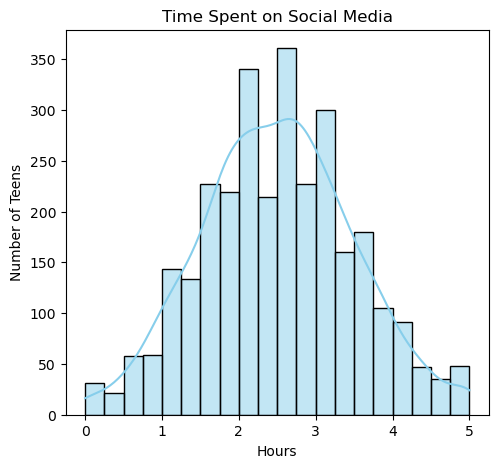

In [ ]:
# Plot side-by-side histograms
plt.figure(figsize=(12, 5))

# Histogram: Time on Social Media
plt.subplot(1, 2, 1)
sns.histplot(df['Time_on_Social_Media'], bins=20, kde=True, color='skyblue')
plt.title("Time Spent on Social Media")
plt.xlabel("Hours")
plt.ylabel("Number of Teens")

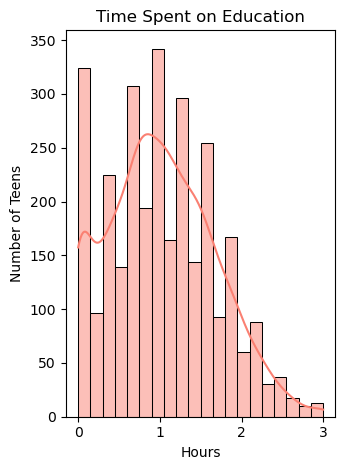

In [25]:
# Histogram: Time on Education
plt.subplot(1, 2, 2)
sns.histplot(df['Time_on_Education'], bins=20, kde=True, color='salmon')
plt.title("Time Spent on Education")
plt.xlabel("Hours")
plt.ylabel("Number of Teens")

plt.tight_layout()
plt.show()

In [27]:
# Calculate medians
social_median = df['Time_on_Social_Media'].median()
education_median = df['Time_on_Education'].median()

print(f"Median Time on Social Media: {social_median} hours")
print(f"Median Time on Education: {education_median} hours")

Median Time on Social Media: 2.5 hours
Median Time on Education: 1.0 hours


In [ ]:
#Histogram Comparison:

#Most teens spend more time on social media than on education.
#Social media hours are often clustered toward the higher end (e.g., 4–6 hours).
#Education hours tend to be lower, often below 3–4 hours.

#Median Comparison:

#If the median time on social media is higher than that for education, it suggests a trend toward digital distraction.
#This could be a red flag for academic focus or time management issues.

### Question 3

- How can we detect and identify outliers in Daily Usage Hours, Exercise Hours, and Screen Time Before Bed among teens using the IQR method?
- Display the records corresponding to these outliers using boxplot.

In [32]:
# Fill missing values (if any)
df.fillna(df.median(numeric_only=True), inplace=True)

# Columns to analyze
columns = ['Daily_Usage_Hours', 'Exercise_Hours', 'Screen_Time_Before_Bed']

# Function to detect outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

In [34]:
# Detect and print outliers
outlier_records = pd.DataFrame()
for col in columns:
    outliers = detect_outliers_iqr(df, col)
    print(f"\nOutliers in {col}:")
    print(outliers[[col]])
    outlier_records = pd.concat([outlier_records, outliers])


Outliers in Daily_Usage_Hours:
      Daily_Usage_Hours
227                10.6
582                10.5
710                11.0
881                10.6
1210               10.3
1549               10.3
1665               10.9
1731               10.6
2400               11.2
2622               10.3
2670               11.5
2746               11.0
2750               10.6
2968               10.3

Outliers in Exercise_Hours:
      Exercise_Hours
56               3.6
126              3.7
608              4.0
632              3.3
784              3.4
963              3.1
1309             3.6
1487             3.4
1546             3.3
1557             3.4
1816             3.5
1847             3.4
2238             3.6
2290             3.1
2366             3.2
2769             3.4
2925             3.3

Outliers in Screen_Time_Before_Bed:
      Screen_Time_Before_Bed
1775                     2.5
1953                     2.5


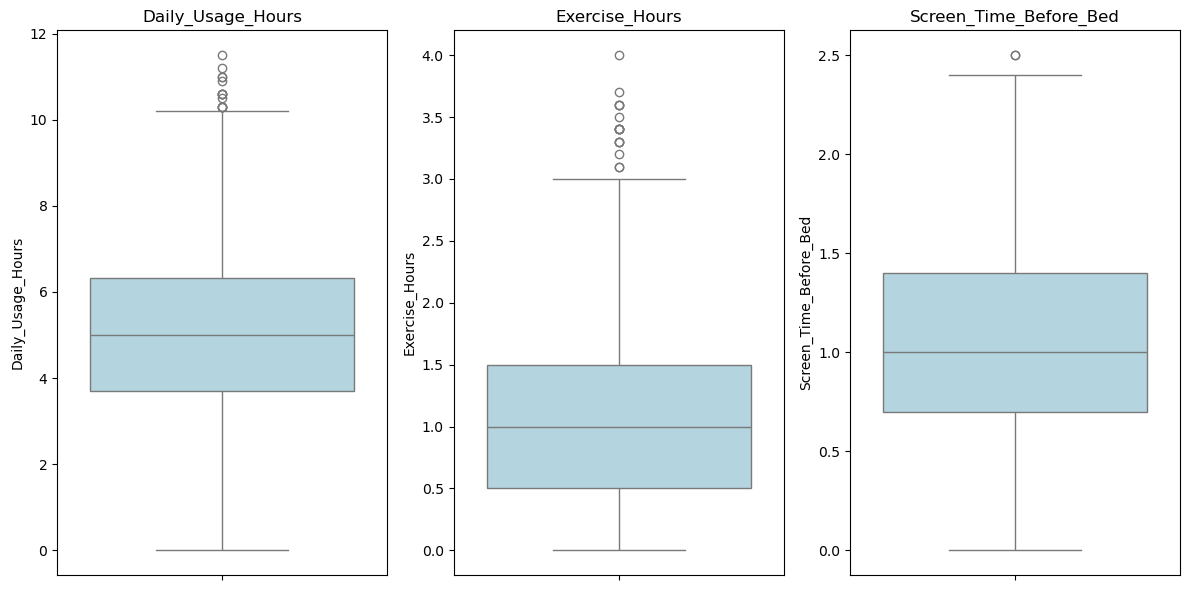

In [36]:
# Drop duplicate rows (in case the same row is an outlier in multiple columns)
outlier_records = outlier_records.drop_duplicates()

# Boxplots for visualizing outliers
plt.figure(figsize=(12, 6))
for i, col in enumerate(columns):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col)
plt.tight_layout()
plt.show()

### Question 4

Analyze the correlation heatmap showing relationships between teen behaviors, screen usage, and mental health indicators.

Focus your attention on the following numeric variables:

- Daily_Usage_Hours, Sleep_Hours, Academic_Performance, Addiction_Level, Time_on_Social_Media,

- Time_on_Gaming, Time_on_Education, Apps_Used_Daily, Anxiety_Level, Depression_Level,

- Self_Esteem, Social_Interactions, Exercise_Hours, Screen_Time_Before_Bed,

- Phone_Checks_Per_Day, Family_Communication, Weekend_Usage_Hours


Identify two strong positive and two strong negative correlation involving any of the above variables.

Explain briefly what these correlations might suggest about teen behavior, wellbeing, or digital habits.

Use specific values from the heatmap to support your observation.

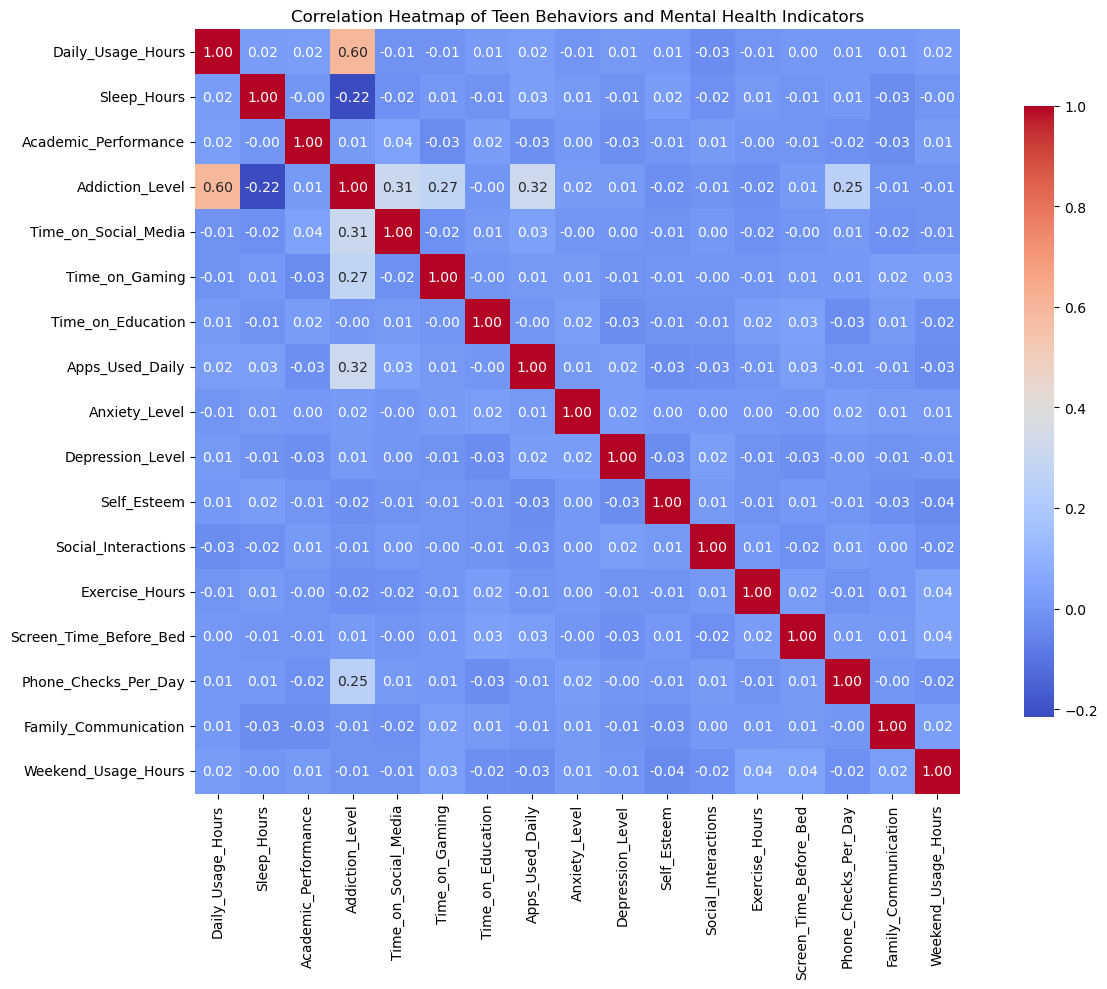

In [39]:
# Fill missing values (numeric only)
df.fillna(df.median(numeric_only=True), inplace=True)

# Focused variables
cols = [
    'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Addiction_Level',
    'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Apps_Used_Daily',
    'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Social_Interactions',
    'Exercise_Hours', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day',
    'Family_Communication', 'Weekend_Usage_Hours'
]

# Compute correlation matrix
correlation_matrix = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap of Teen Behaviors and Mental Health Indicators")
plt.tight_layout()
plt.show()

### Question 5

How does the average addiction level vary across different age groups? Show with line graph

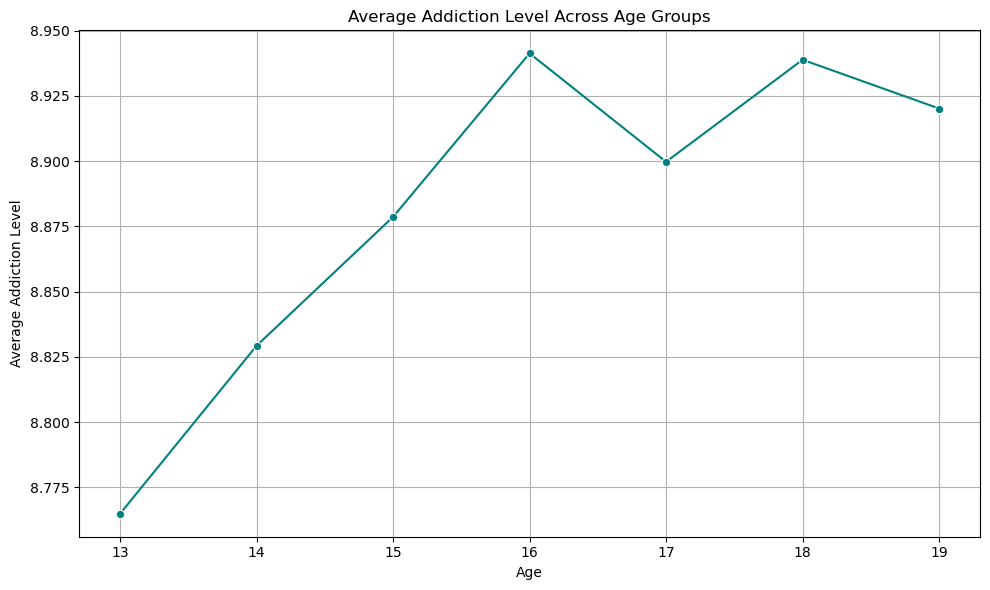

In [42]:
# Fill missing values in Addiction_Level or Age if needed
df = df[df['Addiction_Level'].notnull() & df['Age'].notnull()]

# Group by Age and calculate mean Addiction Level
age_addiction = df.groupby('Age')['Addiction_Level'].mean().reset_index()

# Plot line graph
plt.figure(figsize=(10, 6))
sns.lineplot(data=age_addiction, x='Age', y='Addiction_Level', marker='o', color='teal')
plt.title('Average Addiction Level Across Age Groups')
plt.xlabel('Age')
plt.ylabel('Average Addiction Level')
plt.grid(True)
plt.tight_layout()
plt.show()